# Data Quality Assessment

## Objectives

- Verify dataset integrity.
- Count images per class.
- Detect corrupted images.
- Check image sizes.
- Check image formats.
- Analyze dataset quality before preprocessing.

In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
dataset_path = "../../datasets/food-101/images"

print(dataset_path)

../../datasets/food-101/images


In [4]:
class_names = sorted([
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Total Classes:", len(class_names))

Total Classes: 101


In [5]:
image_counts = []
valid_classes = []

for cls in class_names:

    folder = os.path.join(dataset_path, cls)

    if not os.path.isdir(folder):
        continue

    count = len(os.listdir(folder))

    valid_classes.append(cls)
    image_counts.append(count)

df = pd.DataFrame({
    "Class": valid_classes,
    "Image Count": image_counts
})

df.head()

,Class,Image Count
0,apple_pie,1000
1,baby_back_ribs,1000
2,baklava,1000
3,beef_carpaccio,1000
4,beef_tartare,1000


In [6]:
print(df.describe())

       Image Count
count        101.0
mean        1000.0
std            0.0
min         1000.0
25%         1000.0
50%         1000.0
75%         1000.0
max         1000.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Class        101 non-null    str  
 1   Image Count  101 non-null    int64
dtypes: int64(1), str(1)
memory usage: 1.7 KB


In [9]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
Class          0
Image Count    0
dtype: int64


In [10]:
print("Duplicate Classes :", df.duplicated().sum())

Duplicate Classes : 0


In [11]:
print(df["Image Count"].value_counts())

Image Count
1000    101
Name: count, dtype: int64


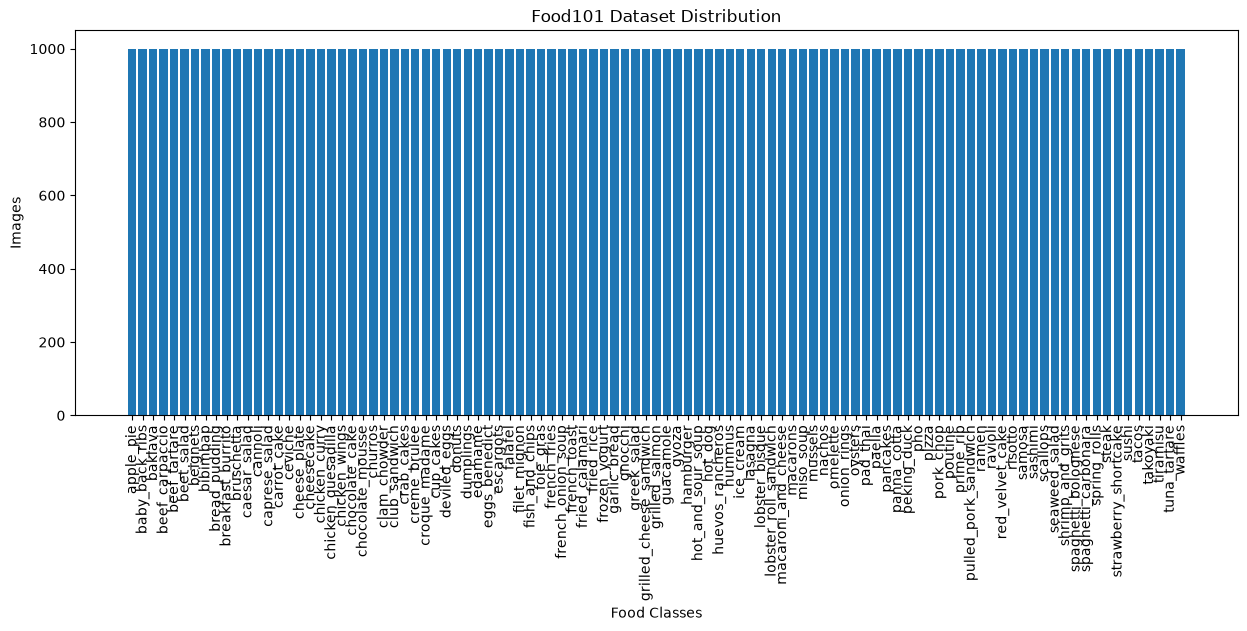

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.bar(df["Class"], df["Image Count"])

plt.xticks(rotation=90)

plt.title("Food101 Dataset Distribution")

plt.xlabel("Food Classes")

plt.ylabel("Images")

plt.show()

In [13]:
sizes = []

for cls in class_names[:10]:

    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder)[:20]:

        img = Image.open(os.path.join(folder, img_name))

        sizes.append(img.size)

sizes[:10]

[(308, 512),
 (512, 512),
 (384, 512),
 (512, 512),
 (512, 512),
 (512, 512),
 (384, 512),
 (382, 512),
 (512, 342),
 (512, 512)]

In [14]:
from collections import Counter

Counter(sizes).most_common(10)

[((512, 512), 113),
 ((512, 384), 23),
 ((384, 512), 17),
 ((512, 341), 7),
 ((512, 382), 5),
 ((382, 512), 4),
 ((512, 289), 3),
 ((306, 512), 3),
 ((308, 512), 2),
 ((512, 342), 2)]

In [15]:
from PIL import Image
import os

corrupted_images = []

for cls in class_names:
    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted_images.append(img_path)

print("Corrupted Images:", len(corrupted_images))

Corrupted Images: 0
